In [19]:
import pandas as pd
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D
from keras.models import Sequential
from keras.datasets import mnist
from tensorflow.keras.layers import MaxPooling2D

In [17]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [18]:
x_train.shape

(60000, 28, 28)

In [39]:
#lenet architecture:
model = Sequential()

model.add(Conv2D(6, kernel_size=(5,5),activation ='tanh', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))
model.add(Conv2D(6, kernel_size=(5,5),activation='tanh', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

from keras.layers import Flatten
model.add(Flatten())

model.add(Dense(120,activation='tanh'))
model.add(Dense(84,activation='tanh'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [41]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 6)        │           906 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        11,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,716 (92.64 KB)

 Trainable params: 23,716 (92.64 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9305 - loss: 0.2327 - val_accuracy: 0.9623 - val_loss: 0.1183
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9681 - loss: 0.1021 - val_accuracy: 0.9729 - val_loss: 0.0824
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9740 - loss: 0.0829 - val_accuracy: 0.9748 - val_loss: 0.0752
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9783 - loss: 0.0681 - val_accuracy: 0.9769 - val_loss: 0.0690
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9802 - loss: 0.0598 - val_accuracy: 0.9787 - val_loss: 0.0662


Text(0, 0.5, 'Model Loss')

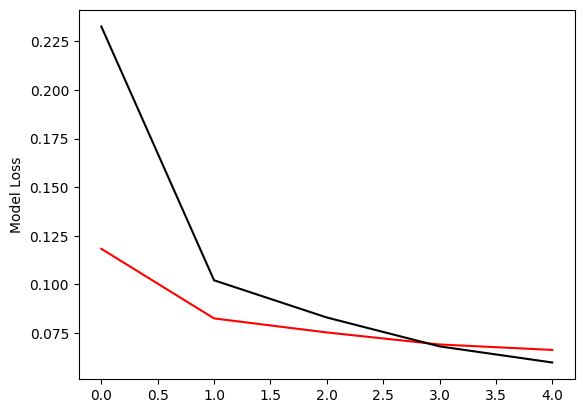

In [43]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_loss'],color='red')
plt.plot(history.history['loss'],color='black')
plt.ylabel('Model Loss')

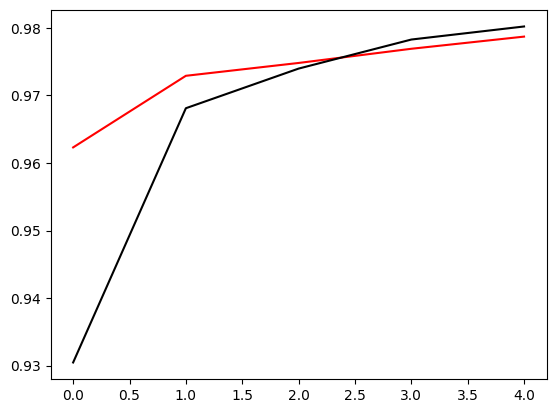

In [44]:
plt.plot(history.history['val_accuracy'],color='red')
plt.plot(history.history['accuracy'],color='black')

In [45]:
y_hat = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [46]:
from sklearn.metrics import accuracy_score
import numpy as np

y_pred_labels = np.argmax(y_hat, axis=1)
accuracy_score(y_test, y_pred_labels)

0.9787